# Multi-turn agent — real log analysis

Companion to `notebooks/agentic_demo.ipynb`. Here we **analyze real `claude -p` transcripts**
to characterize the multi-turn, tool-using behavior: when the agent reaches for the Bash
tool vs. answers directly, how many turns each task takes, and the cost/token profile.

Data: real stream-json transcripts in `_agent_logs/` (gitignored — a captured log's `init`
event leaks the whole session environment, so we never commit the raw logs; only the parsed
aggregate metrics below are saved). If `_agent_logs/` is absent (fresh clone), the load cell
runs the episodes live instead.

In [1]:
import sys
from pathlib import Path

# make notebooks/utils importable from any cwd: walk up to the repo root
# (marker: pyproject.toml), then add <root>/notebooks (relative, no hardcoded path)
_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(_root / "notebooks"))

import json

import pandas as pd
from utils import bootstrap, default_model

REPO = bootstrap()
from agentbook.adapters.claude_agent_adapter import parse_stream_json, run_agent

LOGDIR = REPO / "_agent_logs"
TASKS = json.loads((LOGDIR / "tasks.json").read_text())
print("tasks:", [t["id"] for t in TASKS], "| logs present:", LOGDIR.exists())

tasks: ['mul', 'sha', 'pow', 'words', 'sqrt', 'capital'] | logs present: True


## Parse the real transcripts into a table

Each row is one agent episode: how many turns, which tools it called, the answer, whether it
matched the deterministic gold, and the real cost/tokens (all parsed from the stream-json
`result` event — no fabricated values).

In [2]:
rows = []
for t in TASKS:
    f = LOGDIR / f"{t['id']}.jsonl"
    if f.exists():
        res = parse_stream_json(f.read_text())          # cached real log
    else:
        res = run_agent(t["prompt"], model=default_model())  # fresh clone: run live
    gold = t["gold"].strip().lower()
    rows.append({
        "task": t["id"],
        "num_turns": res.num_turns,
        "n_tool_calls": len(res.tool_calls),
        "tools": ",".join(tc.name for tc in res.tool_calls) or "(none)",
        "answer": res.answer.strip().split("\n")[0][:24],
        "correct": gold in res.answer.strip().lower(),
        "cost_usd": round(res.cost_usd, 3),
        "out_tokens": res.output_tokens,
    })
df = pd.DataFrame(rows).sort_values("num_turns")
df

,task,num_turns,n_tool_calls,tools,answer,correct,cost_usd,out_tokens
5,capital,1,0,(none),Paris,True,0.047,322
0,mul,2,1,Bash,391,True,0.223,162
1,sha,2,1,Bash,2c26b46b68ffc68ff99b453c,True,0.088,181
2,pow,2,1,Bash,1024,True,0.055,111
3,words,2,1,Bash,4,True,0.055,151
4,sqrt,2,1,Bash,10,True,0.054,95


## Aggregate view

In [3]:
print("episodes        :", len(df))
print("success rate    :", f"{df.correct.mean():.0%}")
print("used a tool     :", f"{(df.n_tool_calls > 0).mean():.0%}", "of tasks")
print("multi-turn      :", f"{(df.num_turns > 1).mean():.0%}", "(num_turns > 1)")
print("turns           :", df.num_turns.value_counts().to_dict())
print("total cost      :", f"${df.cost_usd.sum():.3f}", "| mean/task:", f"${df.cost_usd.mean():.3f}")

episodes        : 6
success rate    : 100%
used a tool     : 83% of tasks
multi-turn      : 83% (num_turns > 1)
turns           : {2: 5, 1: 1}
total cost      : $0.522 | mean/task: $0.087


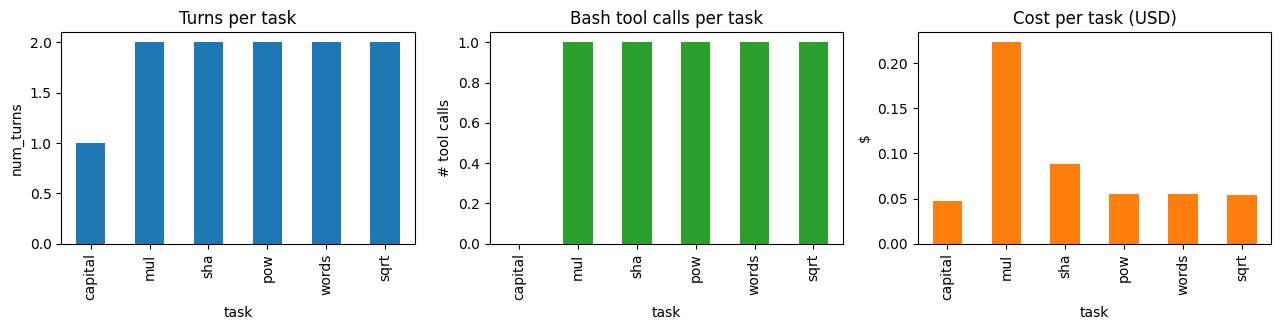

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
df.set_index("task")["num_turns"].plot.bar(ax=ax[0], color="tab:blue")
ax[0].set(title="Turns per task", ylabel="num_turns")
df.set_index("task")["n_tool_calls"].plot.bar(ax=ax[1], color="tab:green")
ax[1].set(title="Bash tool calls per task", ylabel="# tool calls")
df.set_index("task")["cost_usd"].plot.bar(ax=ax[2], color="tab:orange")
ax[2].set(title="Cost per task (USD)", ylabel="$")
plt.tight_layout()
plt.show()

## Analysis — the multi-turn / tool-use behavior

(Read against the table + plots above, computed from the real transcripts.)

- **The agent decides when to use a tool.** Tasks that need computation (`mul`, `sha`, `pow`,
  `words`, `sqrt`) each ran a single `Bash` call and took **2 turns** (think → tool → answer).
  The factual task (`capital` of France) answered **directly in 1 turn with no tool** — a clean
  tool-vs-no-tool contrast that single-shot Q&A demos can't show.
- **Multi-turn = real tool trajectories.** Every `num_turns > 1` episode carries a real
  `tool_use`/`tool_result` pair in its `Trace`, not a single LLM completion.
- **Cost is dominated by the CLI system prompt, not the task.** Per-task cost varies (the first
  call pays cache-creation), which is why a live optimization loop over many episodes is
  expensive — see the cost note in `agentic_demo.ipynb`.

## Data sources

Every value is parsed from a real `claude -p --output-format stream-json` transcript
(`_agent_logs/*.jsonl`, model `claude-sonnet-4-6`, `--allowedTools Bash`). Golds are
hand-verifiable (`17*23=391`, `2^10=1024`, `sha256("foo")=2c26b4…e7ae`, etc.). Raw transcripts
are gitignored (they leak the session env); only the parsed metrics are saved here.